('Pre', datetime.datetime(2012, 3, 19, 8, 4, 16), 896)
('Pre', datetime.datetime(2012, 3, 25, 1, 0, 54), 956)
('Pre', datetime.datetime(2012, 4, 1, 0, 24, 9), 1152)
('Pre', datetime.datetime(2012, 4, 8, 0, 38, 30), 983)
('Post', datetime.datetime(2012, 4, 15, 0, 7, 13), 621)
('Post', datetime.datetime(2012, 4, 22, 0, 8, 47), 594)
('Post', datetime.datetime(2012, 4, 29, 0, 50, 42), 681)
('Post', datetime.datetime(2012, 5, 6, 1, 14, 30), 399)


C:\Users\Htrieu\AppData\Local\Temp\ipykernel_24436\1662504035.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


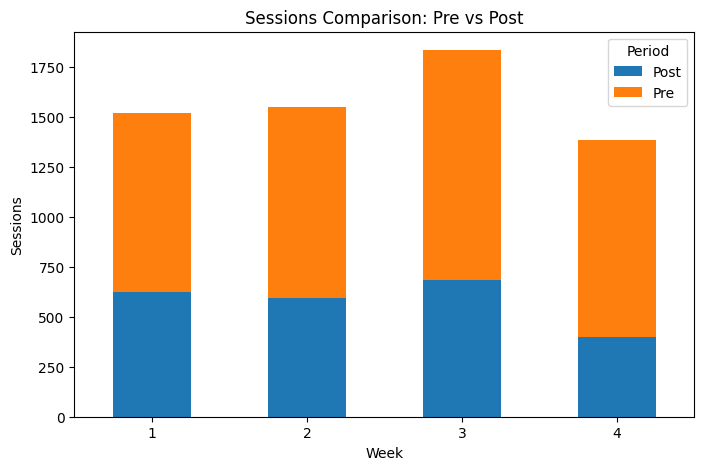

In [8]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Hoangtrieu1409",
    database="mavenfuzzyfactory"
)

cursor = conn.cursor()

query = """
SELECT 
    CASE
        WHEN created_at < '2012-04-15' THEN 'Pre'
        ELSE 'Post'
    END AS Period,
    MIN(created_at) AS week_start_date,
    COUNT(DISTINCT website_session_id) AS session
FROM website_sessions
WHERE created_at < '2012-05-10'
    AND LOWER(utm_source) LIKE 'gsearch'
    AND LOWER(utm_campaign) LIKE 'nonbrand'
GROUP BY WEEK(created_at), 1
ORDER BY WEEK(created_at) ASC;
"""

cursor.execute(query)

for row in cursor:
    print(row)


df = pd.read_sql(query,conn)

pivot_df = df.pivot(
    index="week_start_date",
    columns="Period",
    values="session"
)

pivot_df = pivot_df.sort_index()


df["week"] = df.groupby("Period").cumcount() + 1
pivot_df = df.pivot(
    index="week",
    columns="Period",
    values="session"
)

pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Sessions Comparison: Pre vs Post")
plt.xlabel("Week")
plt.ylabel("Sessions")
plt.xticks(rotation=0)
plt.show()